# Optional extas
Anafibres is also compatible with the `refractiveindex` package, which provides a large database of materials and their refractive indices from [refractiveindex.info](https://refractiveindex.info/) as well as units support from `astropy.units`. If you have these packages installed, you can use them to specify the materials and geometries of your fibres.

In [1]:
import numpy as np
import anafibre as fib
import astropy.units as u

Materials can be specified using the `RefractiveIndexMaterial` class, which takes the same arguments as the `RefractiveIndex` class from the `refractiveindex` package. For example, to specify silicon nitride (Si3N4) and water (H2O) as the core and cladding materials of a step-index fibre, you can do:

In [2]:
SiO2 = fib.RefractiveIndexMaterial('main','SiO2','Malitson')
H2O  = fib.RefractiveIndexMaterial('main','H2O','Hale')

Then you can feed these materials into the fibre constructor as normal:

In [3]:
fibre = fib.StepIndexFibre(
    core_radius=250*u.nm,
    core=SiO2,
    clad=H2O)

And you can get all the modes as usual:

In [4]:
modes=fibre.list_modes_at(380*u.nm)
display(modes)

Mode,λ [nm],V,neff,S0,"(S1, S2, S3) / S0"
HE11,380.00,2.52,1.4130,1.00,"( 0.00, 0.00, 1.00)"
TE01,380.00,2.52,1.3441,1.00,"(-1.00, 0.00, 0.00)"
TM01,380.00,2.52,1.3436,1.00,"( 1.00, 0.00, 0.00)"
HE21,380.00,2.52,1.3413,1.00,"( 0.00, 0.00, 1.00)"


## Dispersion plots
We can also plot the dispersion curves b(V) for all the modes that are supported by the fibre of a given material and geometry. 

In [5]:
solver = dict(N_b=300, tol=1e-9, maxiter=60, complex_tol=1e-7)

wl_min_m = max(float(fibre.core.rangeMin), float(fibre.clad.rangeMin))
wl_max_m = min(float(fibre.core.rangeMax), float(fibre.clad.rangeMax))

V_max = fibre.V(wl_min_m)
V_min = fibre.V(wl_max_m) if np.isfinite(fibre.V(wl_max_m)) else .5#fibre.V(2*u.um)

Vgrid = np.linspace(V_min, V_max, 300)

wlgrid = fibre.wavelength_from_V(Vgrid, rtol=1e-9, maxiter=60, _grid_pts=32) * u.m

wl_ref = wl_min_m
ell_max = fibre.ell_max(wl_ref, **solver)

# Build all branches first, then sort by decreasing n_eff at wl_ref.
branches = []

# ell = 0: TE and TM families
for mode_type, family in [("TE", "TE"), ("TM", "TM")]:
    m_max0 = fibre.m_max(0, wl_ref, mode_type=mode_type, **solver)
    for n in range(1, m_max0 + 1):
        b = fibre.b(ell=0, m=n, wl=wlgrid, mode_type=mode_type, **solver)
        neff_ref = fibre.neff(ell=0, m=n, wl=wl_ref, mode_type=mode_type, **solver)
        branches.append({"label": f"{family}$_{{0{n}}}$", "b": b,
                         "neff": float(np.real(np.asarray(neff_ref)).reshape(-1)[0])})

# ell > 0: HE/EH (internal m odd/even)
for ell in range(1, ell_max + 1):
    m_max = fibre.m_max(ell, wl_ref, **solver)
    for m in range(1, m_max + 1):
        b = fibre.b(ell=ell, m=m, wl=wlgrid, **solver)
        n = (m + 1) // 2
        family = "HE" if (m % 2 == 1) else "EH"
        neff_ref = fibre.neff(ell=ell, m=m, wl=wl_ref, **solver)
        branches.append({"label": f"{family}$_{{{ell}{n}}}$", "b": b,
                         "neff": float(np.real(np.asarray(neff_ref)).reshape(-1)[0])})

branches.sort(key=lambda d: d["neff"], reverse=True)

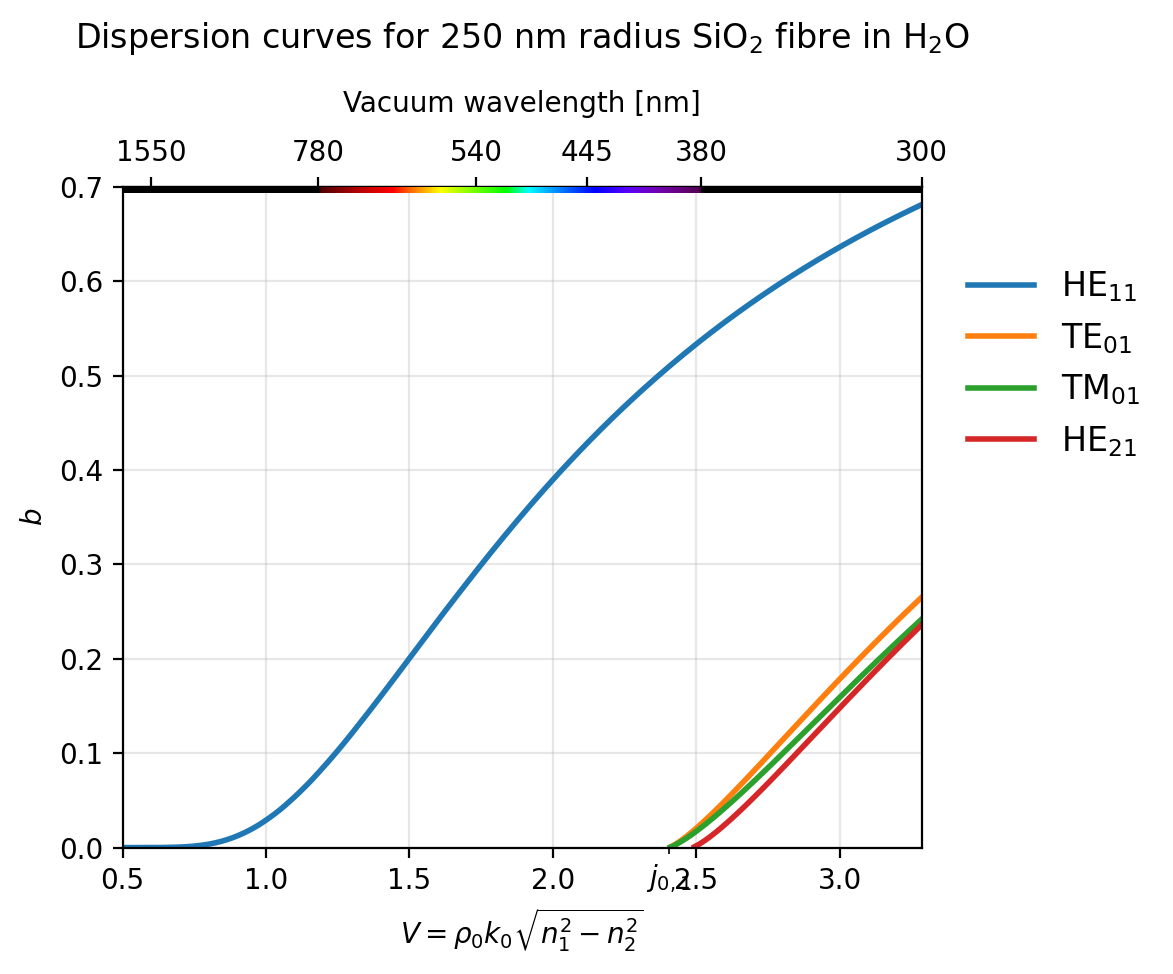

In [6]:
import matplotlib.pyplot as plt
from scipy.special import jn_zeros
from matplotlib.ticker import FixedLocator, FuncFormatter

fig, ax = plt.subplots(figsize=(6, 5))
for br in branches:
    ax.plot(Vgrid, br["b"], lw=2, label=br["label"])

ax.set_xlabel(r'$V = \rho_0k_0 \sqrt{n_1^2 - n_2^2}$')
ax.set_ylabel(r'$b$')
ymax = np.nanmax(np.concatenate([np.ravel(br["b"]) for br in branches]))
ax.set_ylim(0, np.ceil(ymax * 10) / 10)
ax.set_xlim(float(np.nanmin(Vgrid)), float(np.nanmax(Vgrid)))
ax.grid(True, alpha=0.3)
ax.set_title('Dispersion curves for 250 nm radius SiO$_2$ fibre in H$_2$O', fontsize='large', pad=15)

# Build monotonic V<->wavelength mappings for the secondary axis.
wl_nm = wlgrid.to_value(u.nm)

def V_to_nm(v):
    # return np.interp(v, V_unique, wl_unique)
    return fibre.wl_of_V(v)*u.m.to(u.nm)

def nm_to_V(nm):
    # return np.interp(nm, wl_for_inv, V_for_inv)
    return fibre.V(nm*u.nm)

secax = ax.secondary_xaxis('top', functions=(V_to_nm, nm_to_V))
secax.set_xlabel('Vacuum wavelength [nm]', labelpad=10)

# Use controlled wavelength ticks to avoid clutter on very wide ranges.
wl_lo, wl_hi = float(np.nanmin(wl_nm)), float(np.nanmax(wl_nm))

ticks_nm = np.array([wl_lo,380, 445, 540, 780, 1550])
secax.set_xticks(ticks_nm)
secax.set_xticklabels([f'{t:g}' for t in ticks_nm])

# Color strip: colors from wavelength, positioned along the existing V-axis.
fib.plotting.add_visible_spectrum(
    ax,
    position=[0, 1-0.01, 1, 0.01],
    wls=wl_nm,
    xcoords=Vgrid,
)

# Compute Bessel zeros
extra_ticks = [
    jn_zeros(0, 1)[0],  # j_{0,1}
    jn_zeros(1, 1)[0]   # j_{1,1}
]

# Set them as minor ticks
ax.xaxis.set_minor_locator(FixedLocator(extra_ticks))


# Enable minor tick labels
ax.tick_params(axis='x', which='minor', labelsize=10)

# Minor tick formatter
def minor_formatter(x, pos):
    if np.isclose(x, extra_ticks[0]):
        return r"$j_{0,1}$"
    elif np.isclose(x, extra_ticks[1]):
        return r"$j_{1,1}$"
    return ""

ax.xaxis.set_minor_formatter(FuncFormatter(minor_formatter))


# Legend order now follows decreasing n_eff.
ax.legend(loc='upper left', bbox_to_anchor=(1.02, .92), frameon=False, fontsize='large')

plt.tight_layout()
plt.show()